In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

In [21]:
df = pd.read_csv("traffic_accident_dataset.csv")

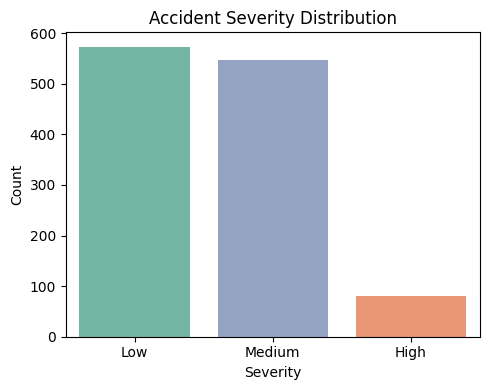

Saved -> severity_distribution.png


In [22]:
plt.figure(figsize=(5, 4))
sns.countplot(x="severity", data=df, order=["Low", "Medium", "High"],
              hue="severity", palette="Set2", legend=False)
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("severity_distribution.png")
plt.show()
print("Saved -> severity_distribution.png")

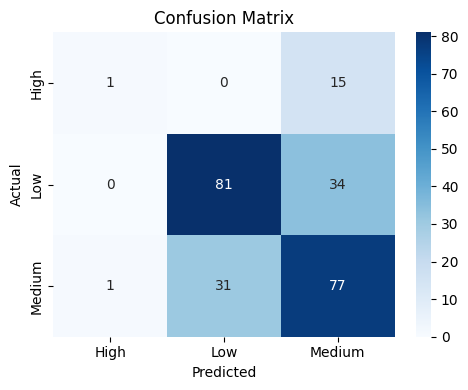

Saved -> confusion_matrix.png


In [23]:
df_enc = df.copy()
encoders = {}
for col in ["weather", "road_type", "light_condition"]:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

target_le = LabelEncoder()
df_enc["severity"] = target_le.fit_transform(df_enc["severity"])

X = df_enc.drop(columns=["severity"])
y = df_enc["severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ----------------------------------------------------------------------
# PLOT 2: Confusion matrix
# ----------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
target_names = target_le.classes_

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
print("Saved -> confusion_matrix.png")

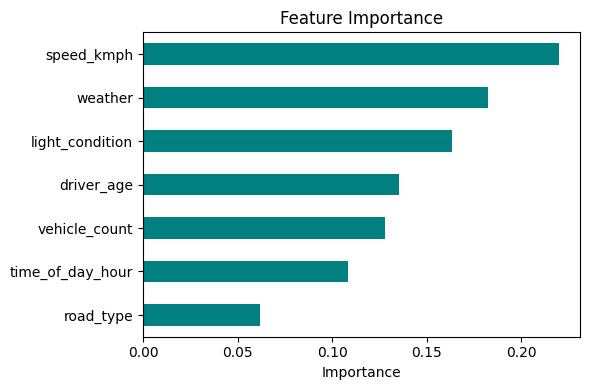

Saved -> feature_importance.png


In [24]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(6, 4))
importances.plot(kind="barh", color="teal")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
print("Saved -> feature_importance.png")